In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
daydf = pd.read_csv("../data/raw/day.csv")
hourdf = pd.read_csv("../data/raw/hour.csv")


In [ ]:
print(daydf.head())
print(hourdf.head())

In [13]:
print(daydf.shape)
print(hourdf.shape)

(731, 16)
(17379, 17)


In [11]:
print(daydf.describe())
print(hourdf.describe())

          instant      season          yr        mnth     holiday     weekday  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean   366.000000    2.496580    0.500684    6.519836    0.028728    2.997264   
std    211.165812    1.110807    0.500342    3.451913    0.167155    2.004787   
min      1.000000    1.000000    0.000000    1.000000    0.000000    0.000000   
25%    183.500000    2.000000    0.000000    4.000000    0.000000    1.000000   
50%    366.000000    3.000000    1.000000    7.000000    0.000000    3.000000   
75%    548.500000    3.000000    1.000000   10.000000    0.000000    5.000000   
max    731.000000    4.000000    1.000000   12.000000    1.000000    6.000000   

       workingday  weathersit        temp       atemp         hum   windspeed  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean     0.683995    1.395349    0.495385    0.474354    0.627894    0.190486   
std      0.465233    0.5448

In [14]:
daydf.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


In [4]:
daydf['dteday'] = pd.to_datetime(daydf['dteday'])

In [17]:
hourdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [5]:
hourdf['dteday'] = pd.to_datetime(hourdf['dteday'])

- transfer datatype of dteday from string to datetime initially

In [5]:
daydf.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [6]:
hourdf.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [8]:
print(daydf.duplicated().sum())

0


In [9]:
print(hourdf.duplicated().sum())

0


- No cleaning action required because there is no duplicate or data missing

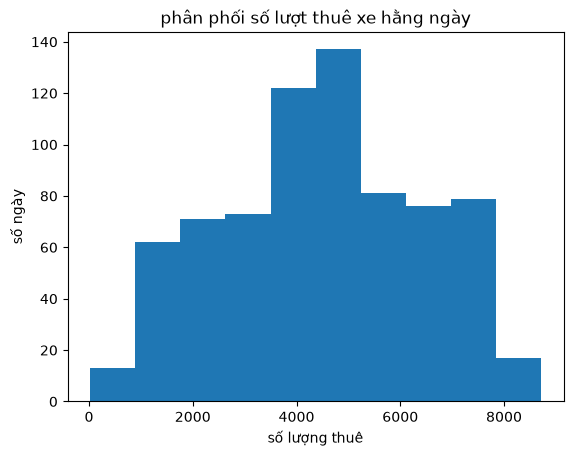

In [28]:
plt.hist(daydf['cnt'])
plt.title("phân phối số lượt thuê xe hằng ngày")
plt.xlabel("số lượng thuê")
plt.ylabel("số ngày")
plt.show()

### cmt
- Most rental count lay between ~ 3500-5500
- approxiamtely bell shaped
- extremely low and high rental count occur infrequently

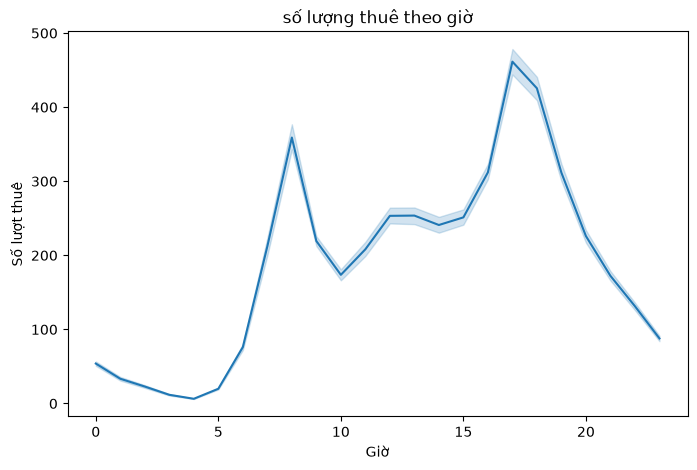

In [34]:
plt.figure(figsize=(8,5))
sns.lineplot(data=hourdf, x='hr', y='cnt')
plt.title("số lượng thuê theo giờ")
plt.xlabel("Giờ")
plt.ylabel("Số lượt thuê")
plt.show()


### comment
- first peak occurs around 8AM, while the higher second one occurs around 17PM (job time and quitting time)
- rental count lowest recording is from 0AM-5AM

### ý nghĩa
- big fluctuation makes it likely to be important for predicting
- repetitive daily cycle show that lag feature may improve forecasting performance

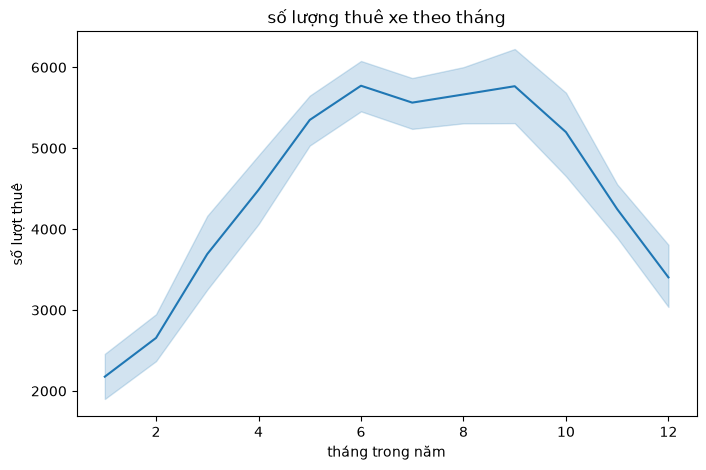

In [36]:
plt.figure(figsize=(8,5))
sns.lineplot(data=daydf, x = 'mnth', y='cnt')
plt.title("số lượng thuê xe theo tháng")
plt.xlabel("tháng trong năm")
plt.ylabel("số lượt thuê")
plt.show()

### cmt
- first few months of the year have low rental count but increase steadily from january to june
- rental count stays quite stable from june to september and decrease for the rest of the year

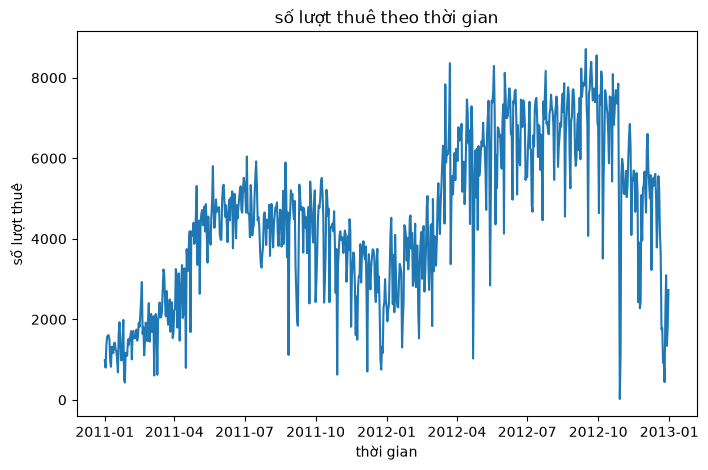

In [12]:
plt.figure(figsize=(8,5))
sns.lineplot(data = daydf, x = 'dteday', y = 'cnt')
plt.title("số lượt thuê theo thời gian")
plt.xlabel("thời gian")
plt.ylabel("số lượt thuê")
plt.show()

### cmt
- upward trend from 2011 to 2012
- a seasonal pattern can be observed, increase in the middle of the year and decrease in both beginning and end of the year

In [ ]:
# weather

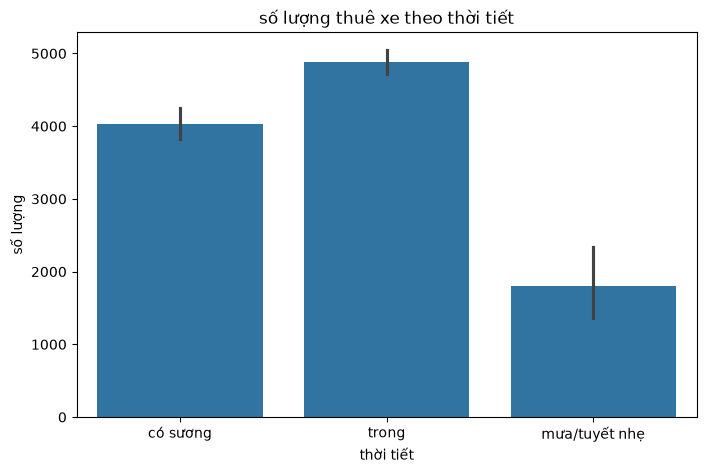

In [20]:
weather_map = {
    1: "trong",
    2: "có sương",
    3: "mưa/tuyết nhẹ",
    4: "mưa tuyết lớn"
}

plot_df = daydf.copy()
plot_df["weathersit"] = plot_df["weathersit"].map(weather_map)

plt.figure(figsize=(8,5))
sns.barplot(data=plot_df, x="weathersit", y="cnt")

plt.title("số lượng thuê xe theo thời tiết")
plt.xlabel("thời tiết")
plt.ylabel("số lượng")

plt.show()

### comment
- clear weather records most rentals
- drop dramatically during mưa/tuyết nhẹ (50%)
- có vẻ thời tiết ảnh hưởng mạnh trên số lượng thuê

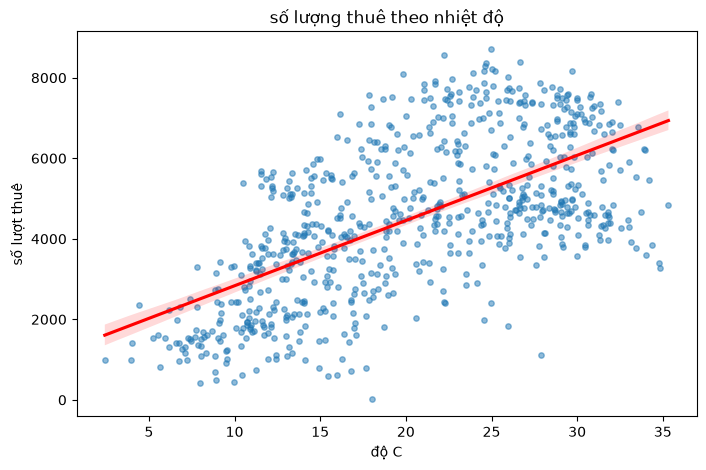

In [27]:
aha = daydf.copy()
aha['temp'] = aha['temp'] * 41 # do cột temp bị chia cho 41 trong dataset gốc
plt.figure(figsize=(8,5))
sns.regplot(data = aha, x = 'temp', y = 'cnt', scatter_kws={"s": 15, "alpha": 0.5}, line_kws={"color": "red"})
plt.title("số lượng thuê theo nhiệt độ")
plt.xlabel("độ C")
plt.ylabel("số lượt thuê")
plt.show()

### cmt
- số lượng thuê nhiều nhất nằm giữa khoảng 20 độ và 30 độ
- nhiệt độ tăng thì nhìn chung, trung bình lượt thuê tăng
- nhưng không tuyến tính vì có sự phân táng khá mạnh so với đường hồi quy
- ở mức 25 độ có sự chênh lệch mạnh, có node dưới 2000 có node nhảy lên 8500 nên còn phụ thuộc vô feature khác

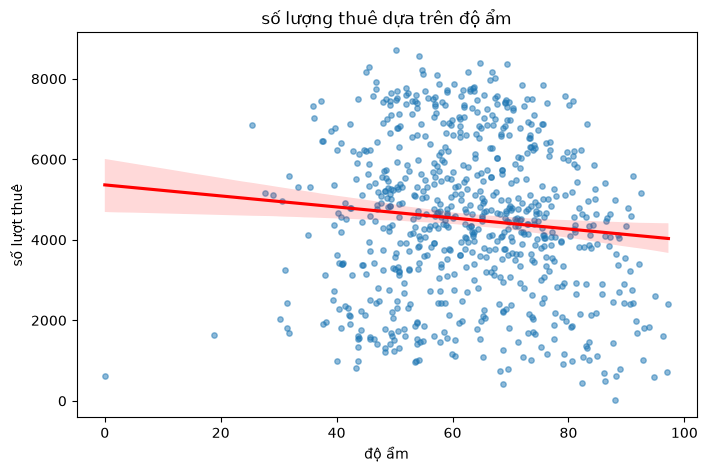

In [28]:
ohno = daydf.copy()
ohno['hum'] = ohno['hum'] * 100 # do độ ẩm bị chia 100 trong data set gốc
plt.figure(figsize=(8,5))
sns.regplot(data = ohno, x = 'hum', y = 'cnt', scatter_kws={"s": 15, "alpha": 0.5}, line_kws={"color": "red"})
plt.title("số lượng thuê dựa trên độ ẩm")
plt.xlabel("độ ẩm")
plt.ylabel("số lượt thuê")
plt.show()

### cmt
- nhìn chung thì số thuê giảm theo độ ẩm tăng
- nhưng sự tương quan khá yếu thì các node phân bố quá rộng quang đường hồi quy
- có chỗ có cùng độ ẩm nhưng chênh lệch rất lớn
- dựa vào mỗi độ ẩm là không đủ

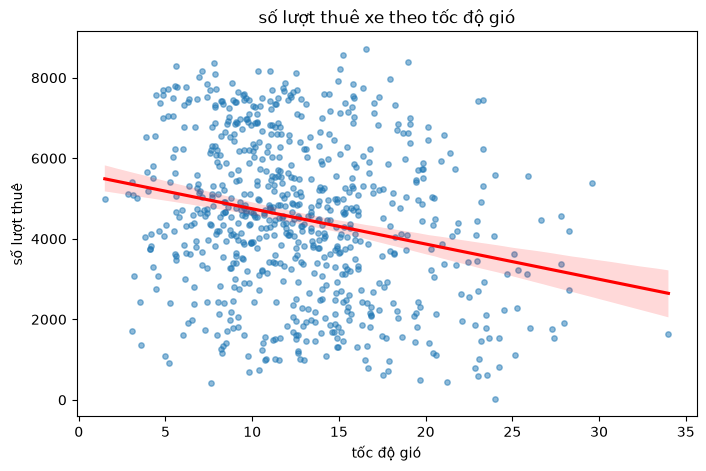

In [29]:
quang = daydf.copy()
quang['windspeed'] = quang['windspeed'] * 67
plt.figure(figsize=(8,5))
sns.regplot(data = quang, x = 'windspeed', y = 'cnt', scatter_kws={"s": 15, "alpha": 0.5}, line_kws={"color": "red"})
plt.title("số lượt thuê xe theo tốc độ gió")
plt.xlabel("tốc độ gió")
plt.ylabel("số lượt thuê")
plt.show()

- Nhìn chung, số lượt thuê xe có xu hướng giảm khi tốc độ gió tăng.
- Tuy nhiên, mối quan hệ này khá yếu do các điểm dữ liệu phân tán rộng quanh đường hồi quy.
- Chỉ dựa vào tốc độ gió là chưa đủ để giải thích sự biến thiên của số lượt thuê xe.

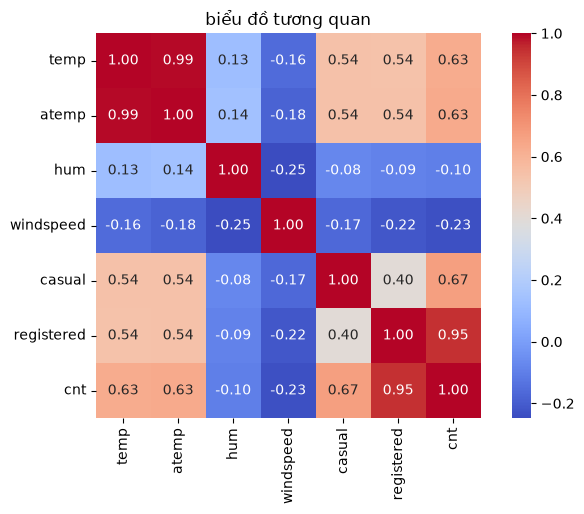

In [31]:
cols = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "casual",
    "registered",
    "cnt"
] # chỉ chọn các biến liên tục

corr = daydf[cols].corr()
plt.figure(figsize=(8,5))
sns.heatmap(data = corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("biểu đồ tương quan")
plt.show()

### cmt
- temp và atemp có sự tương quan chặt chẽ
- cnt và temp có sự tương quan khá mạnh, nghĩa là nhiệt độ càng cao càng nhiều lượt thuê
- ngược lại, hum và windspeed có sự tương quan yếu với cnt

# Summary
- Nhu cầu thuê xe có chu kì rõ rệt theo thời gian, đặc biệt cao với giờ đi làm và tan làm
- những tháng ấm có xu hướng tăng và giảm vào những tháng lạnh
- thời tiết cũng ảnh hướng đến thuê xe, những ngày trời trong có lượt thuê cao nhất, và giảm mạnh vào những ngày mưa/tuyết
- nhiệt độ có sự tương quan khá mạnh với lượt thuê, trong khi độ ẩm và tốc độ gió thì ngược lại


# Hướng phát triển tiếp theo

Dựa trên kết quả EDA, bước tiếp theo của dự án sẽ tập trung vào xây dựng mô hình dự báo số lượt thuê xe.

Các công việc chính bao gồm:

- Xây dựng các đặc trưng phục vụ dự báo chuỗi thời gian (lag features, rolling statistics và calendar features).
- Xây dựng mô hình baseline để làm mốc so sánh.
- Huấn luyện và so sánh nhiều mô hình học máy như Linear Regression, Random Forest và Gradient Boosting.
- Đánh giá mô hình bằng phương pháp chia dữ liệu theo thời gian (TimeSeriesSplit) và các chỉ số MAE, RMSE, MAPE.
- Phân tích mức độ quan trọng của từng đặc trưng (Feature Importance) để xác định những yếu tố ảnh hưởng lớn nhất đến nhu cầu thuê xe.